In [2]:
using QuantumOptics
using DifferentialEquations
using PyPlot

rc("text",usetex=true)
PyPlot.pygui(true)

true

In [34]:
m = 1

#define x-space
x_dist = 0.4
x_min = -x_dist
x_max = x_dist
dx = 0.2
x_steps = Int((x_max - x_min) * 5 + 1)
print(x_steps)

#define Bases
b_x = PositionBasis(x_min, x_max, x_steps)
b_p = MomentumBasis(b_x)

xx = samplepoints(b_x) # x-grid 

#operators to change between position and momentum space
Tpx = transform(b_p, b_x; ket_only=true)
Txp = transform(b_x, b_p; ket_only=true)

#Hamiltonians
x = position(b_x)
p = momentum(b_x)
Hkin = p^2/(2*m)

Hkin_p = Tpx*Hkin*Txp # kinetic Hamiltonian in momentum space

Hkin_ho = p^2/(2*m) # higher-order kinetic term

Hkin_ho_p = Tpx*Hkin_ho*Txp # kinetic Hamiltonian in momentum space

σ = 2.0
V(x) = exp(-x^2/(2*σ))
HV = potentialoperator(b_x, V)

HV_p = Tpx*HV*Txp

#H = Hkin + HV
H = Hkin_ho + HV
H = (dagger(H) + H)/2;

Hfree = Hkin_ho
Hfree = (dagger(Hfree) + Hfree)/2;

println(Hfree)

5Operator(dim=5x5)
  basis: Position(xmin=-0.4, xmax=0.4, N=5)
  69.3957+0.0im        -44.6357+1.471e-14im   17.0493+1.37e-15im  -17.0493+4.92e-15im   44.6357+5.0e-15im
 -44.6357-1.471e-14im   69.3957+0.0im        -44.6357-1.78e-15im   17.0493-1.02e-15im  -17.0493-3.47e-15im
  17.0493-1.37e-15im   -44.6357+1.78e-15im    69.3957+0.0im       -44.6357+1.65e-14im   17.0493-2.95e-15im
 -17.0493-4.92e-15im    17.0493+1.02e-15im   -44.6357-1.65e-14im   69.3957+0.0im       -44.6357-8.96e-15im
  44.6357-5.0e-15im    -17.0493+3.47e-15im    17.0493+2.95e-15im  -44.6357+8.96e-15im   69.3957+0.0im


101

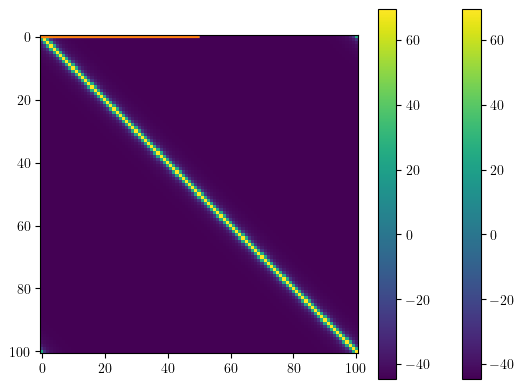

In [46]:
m = 1

#define x-space
x_dist = 10
x_min = -x_dist
x_max = x_dist
dx = 0.2
x_steps = Int((x_max - x_min) * 5 + 1)
print(x_steps)

#define Bases
b_x = PositionBasis(x_min, x_max, x_steps)

xx = samplepoints(b_x) # x-grid 

#Hamiltonians
x = position(b_x)
p = momentum(b_x)
Hkin = p^2/(2*m)

pygui(true)
imshow(abs.(Hkin.data))
gcf()

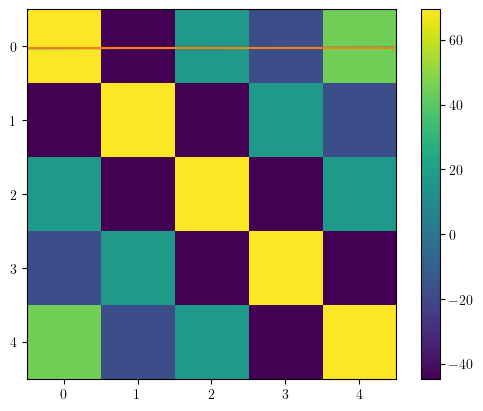

In [41]:
pygui(true)
imshow(real.(Hkin_ho.data))
colorbar()
gcf()

In [13]:
ev, evec = eigenstates(H,5);
ev_free, evec_free = eigenstates(Hfree,5);

In [14]:
ev_free[3]

0.004441321980473124

In [15]:
for ii in 1:5
	println(ev[ii])
	println(ev_free[ii])
end

0.0005351188028080755
0.0004934802200408045
0.0021396422168622215
0.0004934802200599702
0.004815056400266869
0.004441321980473124
0.008555774636870371
0.00444132198049229
0.01336953992041123
0.012337005501337765


In [49]:
(pi / x_dist / 10)^2 / 2

0.0004934802200544679

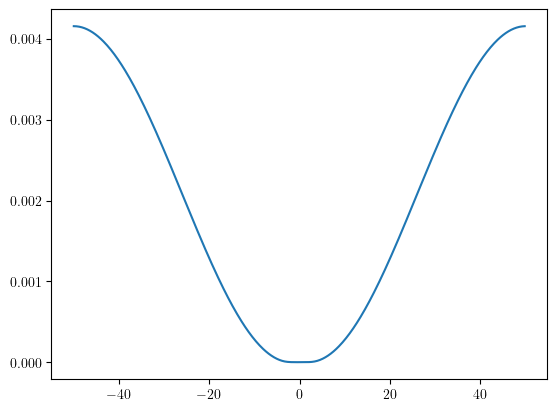

In [21]:
V_l = [V(x) for x=xx]
figure()
# plot(xx,V_l) 
for ii in 1:1
    plot(xx,abs2.(evec[ii].data))
    # plot(xx,imag.(evec[ii].data))
end
display(gcf())

Ket(dim=501)
  basis: Position(xmin=-50, xmax=50, N=501)
  0.05313326160850183 + 0.00014131253324129im
  0.05329343538672404 + 0.00028261950995864im
  0.05345151362189676 + 0.00042391537384637im
  0.05360749009824992 + 0.00056519456901627im
   0.0537613586826565 + 0.00070645154025356im
  0.05391311332487304 + 0.0008476807332265im
  0.05406274805777867 + 0.00098887659466544im
  0.05421025699760888 + 0.00113003357264771im
  0.05435563434418753 + 0.0012711461167427im
   0.0544988743811535 + 0.0014122086782982im
  0.05463997147618734 + 0.00155321571061475im
    0.054778920081232 + 0.00169416166917002im
  0.05491571473271019 + 0.00183504101184942im
  0.05505035005173986 + 0.00197584819917014im
  0.05518282074434658 + 0.00211657769445583im
  0.05531312160167046 + 0.0022572239641219im
  0.05544124750017185 + 0.0023977814778225im
  0.05556719340183141 + 0.00253824470872014im
  0.05569095435434888 + 0.00267860813369376im
   0.0558125254913395 + 0.00281886623351591im
  0.05593190203252261 + 0.00

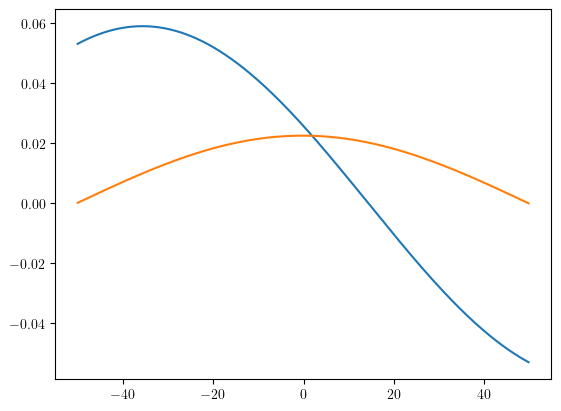

In [27]:
V_l = [V(x) for x=xx]
#plot(xx,V_l)
figure() 
for ii in 1:1
    plot(xx,real.(evec_free[ii].data))
    println(evec_free[ii])
    plot(xx,imag.(evec_free[ii].data))
end
display(gcf())

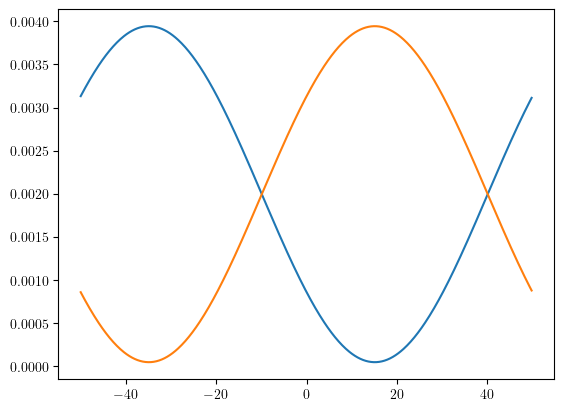

In [9]:
V_l = [V(x) for x=xx]
#plot(xx,V_l)
figure() 
for ii in 1:2
    plot(xx,abs2.(evec_free[ii].data))
end
display(gcf())

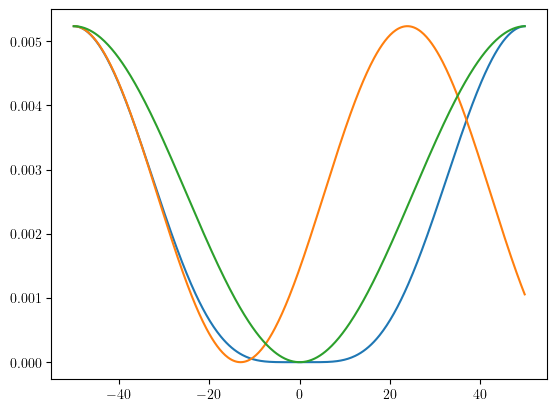

In [74]:
figure() 
for ii in 1:1
    plot(xx, abs2.(evec[ii].data))
    plot(xx, abs2(evec[ii].data[1]) * (cos.((xx .+ x_dist) * 0.0850985199359876) .+ 1) / 2)
    plot(xx, abs2(evec[ii].data[1]) * (cos.((xx .+ x_dist) * 0.06283185307179587) .+ 1) / 2)
end
ax = gca()
# ax[:set_xlim]([-51, -45])
# ax[:set_ylim]([0.0050, 0.0053])
display(gcf())

In [45]:
matplotlib.pyplot.close()

In [56]:
absolute_val = abs2.(evec[1].data)
println(length(absolute_val))

index = 50

amplitude = absolute_val[1] / 2
value = absolute_val[index] - amplitude

derivative = (absolute_val[index + 1] - absolute_val[index]) / dx
# print(xx[index + 1] - xx[index]) 

k = derivative / sqrt(amplitude^2 - value^2)

println(k)
println(pi / x_dist)


501
-0.0850985199359876
0.06283185307179587


In [71]:
using LsqFit

@. model(x, p) = p[1] * (sin(p[2] * x + p[3]) + 1)

p0 = [absolute_val[1], pi / x_dist, x_dist]

fit = curve_fit(model, xx[1:50], absolute_val[1:50], p0)

print(coef(fit))

[0.002617653476198563, 0.08528432369000688, 49.821337775931866]

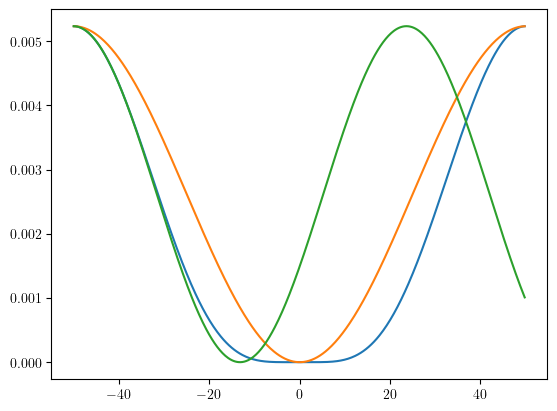

In [73]:
figure() 
for ii in 1:1
    plot(xx, abs2.(evec[ii].data))
    plot(xx, abs2(evec[ii].data[1]) * (cos.((xx .+ x_dist) * 0.06283185307179587) .+ 1) / 2)
    plot(xx, model(xx, coef(fit)))
end
ax = gca()
# ax[:set_xlim]([-51, -45])
# ax[:set_ylim]([0.0050, 0.0053])
display(gcf())

In [8]:
imshow(abs.(Hkin.data))

PyObject <matplotlib.image.AxesImage object at 0x000000006D5C8520>

In [9]:
imshow(abs.(Hkin_p.data))

PyObject <matplotlib.image.AxesImage object at 0x000000006D6178E0>

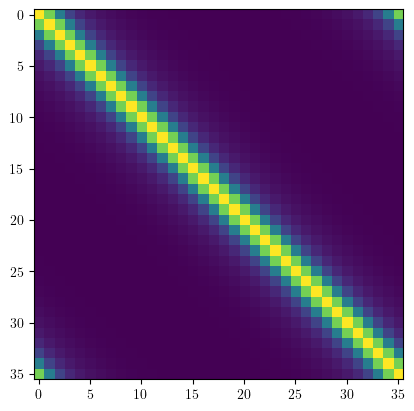

PyObject <matplotlib.image.AxesImage object at 0x354053a00>

In [60]:
imshow(abs.(Hkin_ho.data))

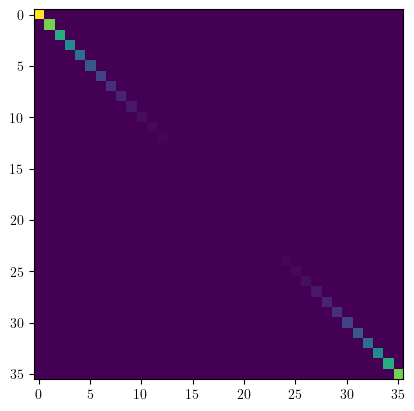

PyObject <matplotlib.image.AxesImage object at 0x353b39060>

In [62]:
imshow(abs.(Hkin_ho_p.data))

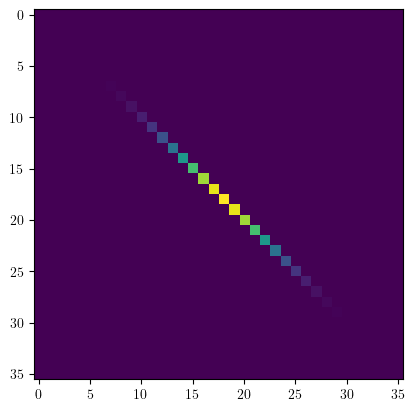

PyObject <matplotlib.image.AxesImage object at 0x351c74340>

In [40]:
imshow(abs.(HV.data))

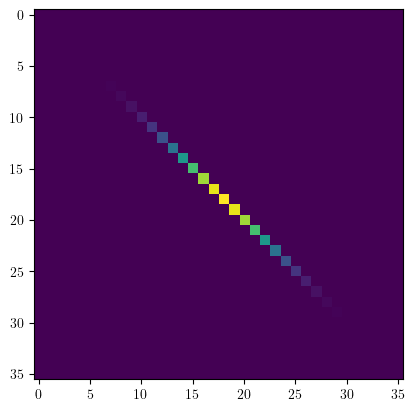

PyObject <matplotlib.image.AxesImage object at 0x351d282b0>

In [41]:
imshow(abs.(HV_p.data))

# Time evolution

In [83]:
xmin = -30
xmax = 30
Npoints = 200

b_position = PositionBasis(xmin, xmax, Npoints)
b_momentum = MomentumBasis(b_position)

Momentum(pmin=-10.471975511965978, pmax=10.471975511965978, N=200)

In [85]:
V0 = 1. # Height of Barrier
d = 5 # Width of Barrier
function V_barrier(x)
    if x < -d/2 || x > d/2
        return 0.
    else
        return V0
    end
end
V_box = potentialoperator(b_position, V_barrier)

Operator(dim=200x200)
  basis: Position(xmin=-30, xmax=30, N=200)sparse([93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109], [93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 200, 200)

In [86]:
Txp = transform(b_position, b_momentum)
Tpx = transform(b_momentum, b_position)
Hkin = LazyProduct(Txp, momentum(b_momentum)^2/2, Tpx)

LazyProduct(dim=200x200)
  basis: Position(xmin=-30, xmax=30, N=200)
  operators: 3

In [88]:
H = LazySum(Hkin, V_box)

LazySum(dim=200x200)
  basis: Position(xmin=-30, xmax=30, N=200)
  operators: 2

┌ Warning: Backwards compatability support of the new return codes to Symbols will be deprecated with the Julia v1.9 release. Please see https://docs.sciml.ai/SciMLBase/stable/interfaces/Solutions/#retcodes for more information
└ @ SciMLBase ~/.julia/packages/SciMLBase/QqtZA/src/retcodes.jl:355
┌ Warning: Backwards compatability support of the new return codes to Symbols will be deprecated with the Julia v1.9 release. Please see https://docs.sciml.ai/SciMLBase/stable/interfaces/Solutions/#retcodes for more information
└ @ SciMLBase ~/.julia/packages/SciMLBase/QqtZA/src/retcodes.jl:355
┌ Warning: Backwards compatability support of the new return codes to Symbols will be deprecated with the Julia v1.9 release. Please see https://docs.sciml.ai/SciMLBase/stable/interfaces/Solutions/#retcodes for more information
└ @ SciMLBase ~/.julia/packages/SciMLBase/QqtZA/src/retcodes.jl:355
┌ Warning: Backwards compatability support of the new return codes to Symbols will be deprecated with the Julia 

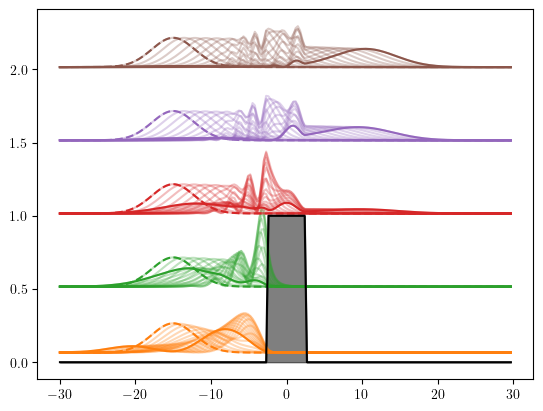

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x32154d780>

In [89]:
xpoints = samplepoints(b_position)

x0 = -15
sigma0 = 4
p0vec = [sqrt(0.1), 1, sqrt(2), sqrt(3), 2]
timecuts = 20

for i_p in 1:length(p0vec)
    p0 = p0vec[i_p]
    Ψ₀ = gaussianstate(b_position, x0, p0, sigma0)
    scaling = 1.0/maximum(abs.(Ψ₀.data))^2/5
    n0 = abs.(Ψ₀.data).^2 .* scaling

    tmax = 2*abs(x0)/(p0+0.2)
    T = collect(range(0.0, stop=tmax, length=timecuts))
    tout, Ψt = timeevolution.schroedinger(T, Ψ₀, H);

    offset = real.(expect(Hkin, Ψ₀))
    plot(xpoints, n0.+offset, "C$i_p--")
    for i=1:length(T)
        Ψ = Ψt[i]
        n = abs.(Ψ.data).^2 .* scaling
        plot(xpoints, n.+offset, "C$i_p", alpha=0.3)
    end
    nt = abs.(Ψt[timecuts].data).^2*scaling
    plot(xpoints, nt.+offset, "C$i_p")
end
y = V_barrier.(xpoints)
fill_between(xpoints, 0, y, color="k", alpha=0.5);
plot(xpoints, y, "k")